Don't forget: M = malignant, B = benign

In [ ]:
# I don't actually know how any of this code works lololol thanks claude you're better than chatgpt for this
# =============================================================================
# BREAST CANCER DIAGNOSIS AGENT — Google Colab
# =============================================================================
# Trains a neural network on labeled CSV data (M = malignant, B = benign).
# Outputs a diagnosis certainty from 0.0 (benign) to 1.0 (malignant).
# Supports runtime CSV upload and Gaussian data augmentation.
# =============================================================================
# This is multi-layer perceptron (MLP), which is also appropriate, not CNN

In [ ]:
# Shouldn't this be run in the terminal?
# ── CELL 1: Install dependencies ─────────────────────────────────────────────
# (Run this cell first; restart runtime if prompted.)

!pip install -q torch scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import io
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ All libraries loaded.")

✅ All libraries loaded.


In [ ]:
# ── CELL 3: Upload & load your CSV ────────────────────────────────────────────
# Option A — upload from your computer (interactive file picker):

from google.colab import files
uploaded = files.upload()                          # select your CSV file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# ── Option B — load from Google Drive (uncomment to use instead) ──────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/YOUR_FOLDER/data.csv')

print(f"✅ Loaded '{filename}': {df.shape[0]} rows, {df.shape[1]} columns")
print(df['diagnosis'].value_counts().rename({1: 'Malignant (M)', 0: 'Benign (B)'}))
df.head()

Saving data.csv to data.csv
✅ Loaded 'data.csv': 569 rows, 33 columns
diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# ── CELL 4: Preprocess ────────────────────────────────────────────────────────

# Drop ID column if present (non-informative)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Drop any fully-empty trailing columns
df = df.dropna(axis=1, how='all')

# Encode target: M → 1 (malignant), B → 0 (benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

if df['diagnosis'].isna().any():
    raise ValueError("Unexpected values in 'diagnosis' column. Expected 'M' or 'B'.")

# Separate features and labels
FEATURE_COLS = [c for c in df.columns if c != 'diagnosis']
X = df[FEATURE_COLS].values.astype(np.float32)
y = df['diagnosis'].values.astype(np.float32)

print(f"✅ Features: {len(FEATURE_COLS)} | Samples: {len(y)}")
print(f"   Malignant: {int(y.sum())}  |  Benign: {int((1-y).sum())}")

✅ Features: 30 | Samples: 569
   Malignant: 212  |  Benign: 357


In [ ]:
# ── CELL 5: Train / Validation / Test split ───────────────────────────────────

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y # test size changed from 0.15
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

# Normalise (fit only on training data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"✅ Split — Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

✅ Split — Train: 364  Val: 91  Test: 114


In [ ]:
# ── CELL 6: Data augmentation ─────────────────────────────────────────────────
# Adds copies of training samples with small Gaussian noise.
# Increase AUGMENT_FACTOR for more augmentation (e.g. 3 = triple the data).

AUGMENT_FACTOR = 2     # how many extra copies to add  (0 = no augmentation)
NOISE_STD      = 0.05  # std of Gaussian noise (in normalised feature space)

def augment(X, y, factor=2, noise_std=0.05, seed=42):
    """Return X, y with `factor` noisy copies of each sample appended."""
    if factor == 0:
        return X, y
    rng = np.random.RandomState(seed)
    copies_X, copies_y = [X], [y]
    for _ in range(factor):
        noise = rng.normal(0, noise_std, size=X.shape).astype(np.float32)
        copies_X.append(X + noise)
        copies_y.append(y)
    return np.vstack(copies_X), np.concatenate(copies_y)

X_train_aug, y_train_aug = augment(X_train, y_train, AUGMENT_FACTOR, NOISE_STD)
print(f"✅ Augmented training set: {len(X_train)} → {len(X_train_aug)} samples")

✅ Augmented training set: 364 → 1092 samples


In [ ]:
# ── CELL 7: Build PyTorch DataLoaders ─────────────────────────────────────────

BATCH_SIZE = 32

def to_loader(X, y, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train_aug, y_train_aug, shuffle=True)
val_loader   = to_loader(X_val, y_val, shuffle=False)
test_loader  = to_loader(X_test, y_test, shuffle=False)

In [ ]:
# ── CELL 8: Define the neural network agent ───────────────────────────────────

class CancerDiagnosisAgent(nn.Module):
    """
    Fully-connected neural network.
    Input  : 30 normalised tumour features
    Output : single sigmoid value in [0, 1]
               → 0.0 = confident benign
               → 1.0 = confident malignant
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()           # outputs probability in [0, 1]
        )

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

model = CancerDiagnosisAgent(input_dim=X_train.shape[1]).to(device)
print(model)

✅ Using device: cuda
CancerDiagnosisAgent(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
    (11): Sigmoid()
  )
)


In [ ]:
# ── CELL 9: Training ──────────────────────────────────────────────────────────

EPOCHS        = 100
LEARNING_RATE = 1e-3
PATIENCE      = 15    # early-stopping patience (epochs without val improvement)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_loss = float('inf')
best_weights  = None
patience_ctr  = 0
history       = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # ── Validate ──
    model.eval()
    val_loss, val_preds, val_true = 0.0, [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds    = model(X_batch)
            val_loss += criterion(preds, y_batch).item() * len(X_batch)
            val_preds.extend(preds.cpu().numpy().flatten())
            val_true.extend(y_batch.cpu().numpy().flatten())
    val_loss /= len(val_loader.dataset)
    val_auc   = roc_auc_score(val_true, val_preds)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"⏹  Early stop at epoch {epoch}  (best val loss: {best_val_loss:.4f})")
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | val_AUC: {val_auc:.4f}")

# Restore best weights
model.load_state_dict(best_weights)
print("\n✅ Training complete. Best weights restored.")

Epoch   1 | train_loss: 0.4856 | val_loss: 0.2886 | val_AUC: 0.9886
Epoch  10 | train_loss: 0.0576 | val_loss: 0.0742 | val_AUC: 0.9948
Epoch  20 | train_loss: 0.0302 | val_loss: 0.0609 | val_AUC: 0.9933
Epoch  30 | train_loss: 0.0288 | val_loss: 0.0715 | val_AUC: 0.9938
⏹  Early stop at epoch 40  (best val loss: 0.0578)

✅ Training complete. Best weights restored.


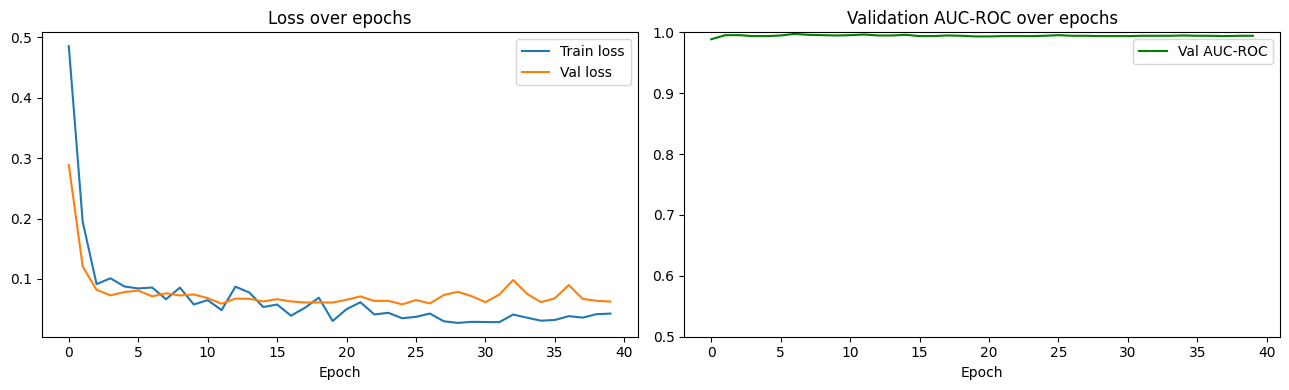

✅ Training curves saved as 'training_curves.png'.


In [ ]:
# ── CELL 10: Plot training curves ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_auc'], color='green', label='Val AUC-ROC')
axes[1].set_title('Validation AUC-ROC over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved as 'training_curves.png'.")

  Test Accuracy : 97.37%
  Test AUC-ROC  : 0.9954
               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        72
Malignant (M)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



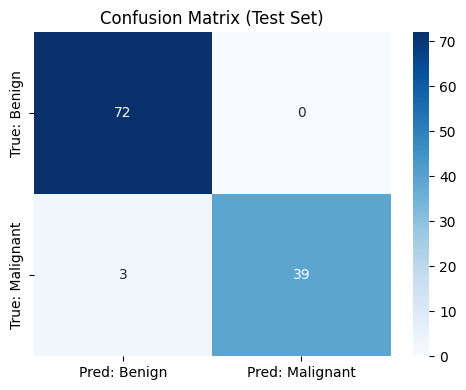

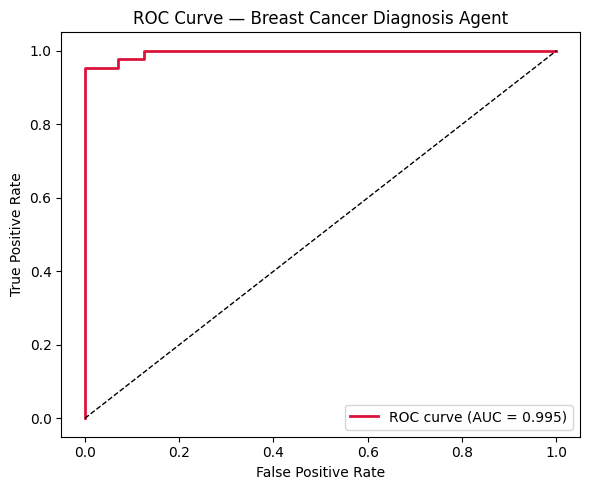

✅ Evaluation plots saved.


In [ ]:
# ── CELL 11: Evaluate on held-out test set ────────────────────────────────────

model.eval()
test_preds_prob, test_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        prob = model(X_batch).cpu().numpy().flatten()
        test_preds_prob.extend(prob)
        test_true.extend(y_batch.numpy().flatten())

test_preds_prob = np.array(test_preds_prob)
test_true       = np.array(test_true)
test_preds_bin  = (test_preds_prob >= 0.5).astype(int)

acc = accuracy_score(test_true, test_preds_bin)
auc = roc_auc_score(test_true, test_preds_prob)

print("=" * 45)
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Test AUC-ROC  : {auc:.4f}")
print("=" * 45)
print(classification_report(test_true, test_preds_bin,
                             target_names=['Benign (B)', 'Malignant (M)']))

# Confusion matrix
cm = confusion_matrix(test_true, test_preds_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Benign', 'Pred: Malignant'],
            yticklabels=['True: Benign', 'True: Malignant'])
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(test_true, test_preds_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Breast Cancer Diagnosis Agent')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print("✅ Evaluation plots saved.")

In [ ]:
# ── CELL 12: Diagnose new samples ─────────────────────────────────────────────
# Pass a dict or a 1-row DataFrame with the same feature columns as training.
# Returns certainty in [0, 1]:  0.0 = benign,  1.0 = malignant.

def diagnose(sample, threshold=0.5):
    """
    Diagnose a new tumour sample.

    Parameters
    ----------
    sample    : dict or pd.DataFrame (1 row) with the 30 feature columns
    threshold : float — decision boundary (default 0.5)

    Returns
    -------
    dict with keys:
        'certainty'  – float in [0, 1]
        'diagnosis'  – 'Malignant' or 'Benign'
        'confidence' – human-readable confidence level
    """
    model.eval()
    if isinstance(sample, dict):
        sample = pd.DataFrame([sample])
    values = sample[FEATURE_COLS].values.astype(np.float32)
    values = scaler.transform(values)
    tensor = torch.tensor(values, dtype=torch.float32).to(device)
    with torch.no_grad():
        certainty = model(tensor).item()
    label = 'Malignant' if certainty >= threshold else 'Benign'
    conf  = abs(certainty - 0.5) / 0.5          # 0 = uncertain, 1 = certain
    conf_label = ('Low' if conf < 0.4 else 'Moderate' if conf < 0.75 else 'High')
    return {
        'certainty' : round(certainty, 4),
        'diagnosis' : label,
        'confidence': conf_label
    }


# ── Example: diagnose the first row of the original dataset ──────────────────
sample_row = df.iloc[[0]].copy()
result = diagnose(sample_row)
actual = 'Malignant' if df.iloc[0]['diagnosis'] == 1 else 'Benign'

print(f"\n── Sample diagnosis ──────────────────────────")
print(f"  Certainty  : {result['certainty']}  (0=benign → 1=malignant)")
print(f"  Diagnosis  : {result['diagnosis']}")
print(f"  Confidence : {result['confidence']}")
print(f"  Actual     : {actual}")


── Sample diagnosis ──────────────────────────
  Certainty  : 1.0  (0=benign → 1=malignant)
  Diagnosis  : Malignant
  Confidence : High
  Actual     : Malignant


In [ ]:
# ── CELL 13: Save model & scaler ─────────────────────────────────────────────
# Saves to Colab's local storage; copy to Drive for persistence.

import pickle

torch.save(model.state_dict(), 'cancer_agent_weights.pt')

with open('cancer_agent_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('cancer_agent_feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

print("✅ Saved: cancer_agent_weights.pt")
print("✅ Saved: cancer_agent_scaler.pkl")
print("✅ Saved: cancer_agent_feature_cols.pkl")

# Optional: copy to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# for f in ['cancer_agent_weights.pt','cancer_agent_scaler.pkl','cancer_agent_feature_cols.pkl']:
#     shutil.copy(f, f'/content/drive/MyDrive/YOUR_FOLDER/{f}')
# print("✅ Files copied to Google Drive.")

✅ Saved: cancer_agent_weights.pt
✅ Saved: cancer_agent_scaler.pkl
✅ Saved: cancer_agent_feature_cols.pkl


In [ ]:
# ── CELL 14: Load model & run inference (later / new session) ─────────────────

# from google.colab import files
# import pickle, torch
#
# # Re-upload or load from Drive
# uploaded = files.upload()   # upload weights + scaler + feature_cols files
#
# with open('cancer_agent_scaler.pkl', 'rb') as f:
#     scaler = pickle.load(f)
# with open('cancer_agent_feature_cols.pkl', 'rb') as f:
#     FEATURE_COLS = pickle.load(f)
#
# model = CancerDiagnosisAgent(input_dim=len(FEATURE_COLS)).to(device)
# model.load_state_dict(torch.load('cancer_agent_weights.pt', map_location=device))
# model.eval()
# print("✅ Model loaded and ready for inference.")